# Предиктивная модель маркетинга бизнес-карт
---

## Продуктовая постановка задачи

* **Проблема:** Конверсия в бизнес-карты низкая (8%), колл-центр тратит ресурсы на нецелевых клиентов.
* **Целевая аудитория:** Действующие клиенты банка (ИП/ООО).
* **Продуктовая гипотеза:** Если ранжировать клиентов с помощью ML и звонить только клиентам с наибольшей вероятностью согласия, поднимется конверсия (Lift>1) и будет сэкономлена часть бюджета колл-центра.
* **Ключевые метрики:** 
  * ROC-AUC
  * Lift, Precision, дополнительная прибыль
* **MVP:** Sklearn Pipeline + CatBoost модель + Streamlit интерфейс для операторов

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (StandardScaler, OrdinalEncoder, FunctionTransformer)
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, precision_score, recall_score
from sklearn.impute import SimpleImputer
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import joblib
from sklearn.metrics import confusion_matrix
import shap
import gigachat
from gigachat import GigaChat
import warnings 
warnings.filterwarnings('ignore')
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import CalibratedClassifierCV


## 1.1 Описание этапа подготовки данных

Исходные данные содержали конфиденциальную информацию. Данный этап был проведен вне данного ноутбука в защищенном контуре. На этапе первичной подготовки были выполнены следующие преобразования:

* **Анонимизация**: переименование колонок для исключения утечки терминологии.

* **Создание целевой переменной у**:

        df['y'] = df['response_name'].map(lambda x: 0 if x in ['Отказ клиента','Отказ банка'] else 1)

* **Обработка каналов привлечения (source)**: группировка редких категорий в 'Другое', заполнение пропусков как 'unknown'.

* **Разделение поля с типом и городом** на type (ММБ/СКБ) и region (Город). Редкие регионы объединены в 'Другое':

        region_counts = df['region'].value_counts()
        min_count = 30
        top_regions = region_counts[region_counts >= min_count].index
        df['region'] = df['region'].where(df['region'].isin(top_regions), 'Другое')

* **Из дат коммуникации** созданы day и month. Рассчитана tenure_days (давность клиента):

        df['date'] = pd.to_datetime(df['date'])
        df['start_date'] = pd.to_datetime(df['start_date'])
        df['day'] = df['date'].dt.day
        
        month_dict = {
            1: 'Январь', 2: 'Февраль', 3: 'Март',
            4: 'Апрель', 5: 'Май', 6: 'Июнь',
            7: 'Июль', 8: 'Август', 9: 'Сентябрь',
            10: 'Октябрь', 11: 'Ноябрь', 12: 'Декабрь'
        }
        df['month'] = df['date'].dt.month.map(month_dict)
        df['tenure_days'] = (df['date'] - df['start_date']).dt.days

* **Создан признак** was_closed_contact на основе сравнения даты закрытия клиента и даты коммуникации.
        
        df['was_closed_at_contact'] = (df['end_date'] < df['date']).astype(int)

* **Агрегация**: посчитано количество коммуникаций с клиентом в рамках МК - признак campaign.


## 1.2 Утечка данных и добавление новых признаков

В процессе разведочного анализа и первых итерациях моделирования была выявлена **утечка данных**.

С признаком **campaign** (количество коммуникаций с клиентом в рамках МК) модель имела ROC-AUC ≈ 0.99. Анализ бизнес-логики показал, что данный признак является следствием. Количество контактов растет в том случае, если клиент уже согласился и с ним ведется диалог. Включение этого признака невозможно, так как на момент принятия решения о звонке неизвестно сколько всего будет коммуникаций с данным клиентом. 

После удаления признака качество модели снизилось (ROC-AUC ≈ 0.62). Для повышения предсказательной силы из дополнительных источников были добавлены признаки age (возраст), credit_amount (остаток по кредиту), deposit_amount (остаток по депозиту), а так же флаги активности по кредитам/депозитам credite_active, deposit_active. 

## 2. EDA

Значения столбцов:

* y - целевая переменная
* region - регион 
* type - тип клиента (ММБ/СКБ)
* source - канал привлечения клиента
* is_clientfinalta_active - флаг активного клиента
* is_client_new - флаг нового клиента 
* was_closed_at_contact - флаг закрытого клиента на момент коммуникации
* day - день
* month - месяц
* tenure_days - давность клиента в днях
* campaign - кол-во коммуникаций с клиентом в рамках МК
* age - возраст
* credit_amount - остаток по кредитам
* deposit_amount - остаток по депозитам
* credite_active - флаг активности по кредитам
* deposit_amount - флаг активности по депозитам

In [51]:
sns.set(style='darkgrid', palette='deep')

plt.rcParams['figure.figsize'] = 8, 5
plt.rcParams['font.size'] = 12

In [52]:
df = pd.read_csv('cleaned_finall_dataset.csv', encoding='cp1251',sep=';')

In [53]:
y_counts = df['y'].value_counts()
print('\nБаланс целевой переменной y:')
print(y_counts)
print('Доля 1 (согласие): {:.2%}'.format(y_counts.get(1, 0) / len(df)))


Баланс целевой переменной y:
0    1437
1     128
Name: y, dtype: int64
Доля 1 (согласие): 8.18%


In [54]:
print('Размеры датафрейма:', df.shape)
print('\nТипы колонок:')
print(df.dtypes)

display(df.head())

numeric = ['tenure_days', 'day', 'month', 'campaign','age', 'credit_amount','deposit_amount']
display(df[numeric].describe().T)

cat_cols = ['type', 'region', 'source']
for col in cat_cols:
    print(f'\n{col} (топ‑5):')
    print(df[col].value_counts().head())

Размеры датафрейма: (1565, 16)

Типы колонок:
is_client_new                int64
is_clientfinalta_active      int64
y                            int64
type                        object
region                      object
source                      object
was_closed_at_contact        int64
tenure_days                float64
day                          int64
month                        int64
campaign                     int64
age                          int64
credit_amount              float64
credite_active              object
deposit_active              object
deposit_amount               int64
dtype: object


,is_client_new,is_clientfinalta_active,y,type,region,source,was_closed_at_contact,tenure_days,day,month,campaign,age,credit_amount,credite_active,deposit_active,deposit_amount
0,0,1,0,ММБ,Краснодар,Онлайн,0,780.0,15,3,6,33,0.0,N,Y,0
1,0,0,0,ММБ,Химки,Онлайн,0,781.0,15,3,15,32,0.0,N,Y,0
2,0,1,0,ММБ,Калининград,Партнер,0,933.0,14,8,7,47,0.0,N,Y,0
3,0,1,0,ММБ,Краснодар,unknown,0,773.0,15,3,5,44,0.0,N,Y,0
4,0,1,0,ММБ,Тольятти,Партнер,0,834.0,15,5,3,36,0.0,N,Y,0


,count,mean,std,min,25%,50%,75%,max
tenure_days,1549.0,976.006456,762.302464,-951.0,443.0,729.0,1314.0,5728.00
day,1565.0,16.481150,6.257512,1.0,13.0,15.0,22.0,31.00
month,1565.0,6.145687,2.610571,1.0,4.0,6.0,8.0,12.00
campaign,1565.0,19.442173,48.551592,1.0,3.0,6.0,11.0,624.00
age,1565.0,41.886262,10.420131,22.0,35.0,40.0,48.0,121.00
credit_amount,1565.0,36866.602805,315446.924270,0.0,0.0,0.0,0.0,8888888.88
deposit_amount,1565.0,42041.533546,560720.992012,0.0,0.0,0.0,0.0,13000000.00



type (топ‑5):
ММБ    1558
СКБ       7
Name: type, dtype: int64

region (топ‑5):
 Санкт-Петербург           90
 Краснодар                 87
 Москва Тер-рия "Север"    82
Другое                     79
 Москва Тер-рия "Юг"       72
Name: region, dtype: int64

source (топ‑5):
unknown           1133
Онлайн             237
Партнер            148
Отделение           31
Выездной канал       9
Name: source, dtype: int64


Видно, что в поле tenure_days есть пропуски, а так же отрицательные значения (выбросы). В поле возраст максимальное значение составляет 121, что так же является выбросом. 

В поле type практически весь портфель относится к типу ММБ. Признак почти не дифференцирует клиентов, поэтому его влияние на доходность, риск или поведение минимально. Признак подлежит удалению.

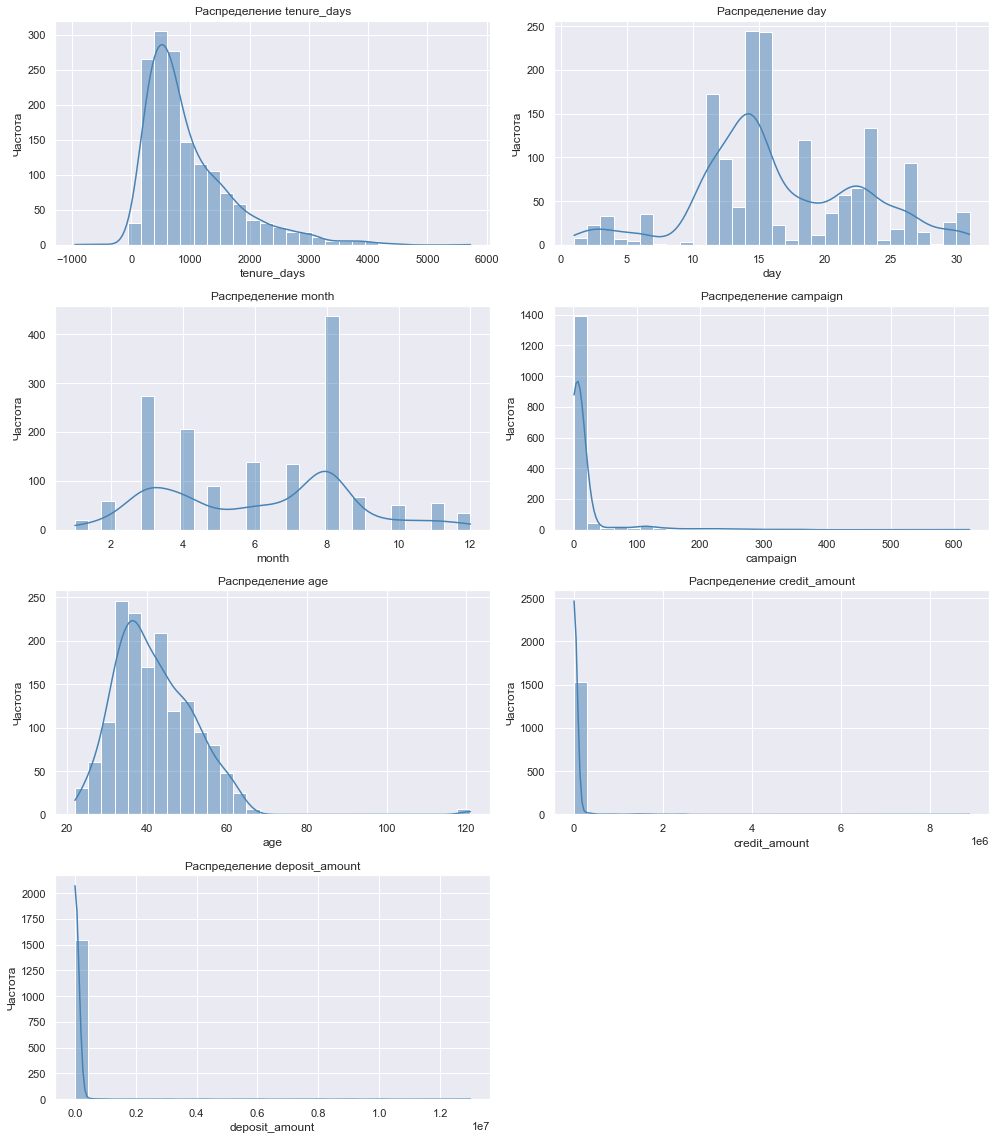

In [55]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(numeric):
    if i < len(axes):
        sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue', bins=30)
        axes[i].set_title(f'Распределение {col}', fontsize=12)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Частота')

if len(numeric) < len(axes):
    for j in range(len(numeric), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Распределение возраста близко к нормальному с пиком в районе 35-45 лет. Это соответствует целевой аудитории банковских продуктов. Выбросов практически нет, за исключением единичных случаев. Для признаков campaign, deposit_amount и credit_amount до 80-90% значений сосредоточено в диапазоне минимальных значений, после чего наблюдается резкий спад и длинный хвост вправо. Такая структура указывает на необходимость использования логарифмического преобразования для deposit_amount и credit_amount. 
Распределение tenure_days имеет правостороннюю асимметрию. Большинство клиентов имеют небольшой стаж (до 1000 дней). Это типично для клиентской базы. 

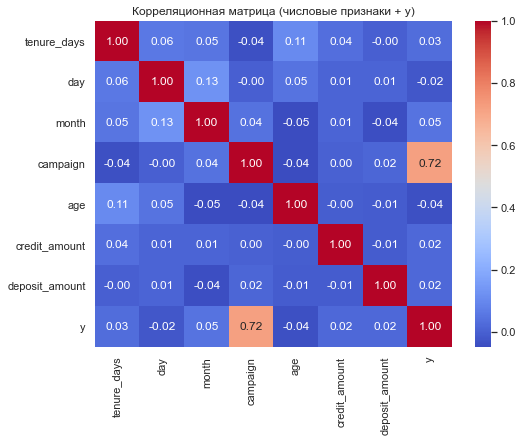

In [56]:
corr = df[numeric + ['y']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица (числовые признаки + y)')
plt.show()

Признак сampaign имеет высокую линейную корреляцию с целевой переменной. Это подтверждает вывод об утечке данных: кол-во контактов растет только после того, как клиент предварительно дал согласие. Признак подлежит удалению. 

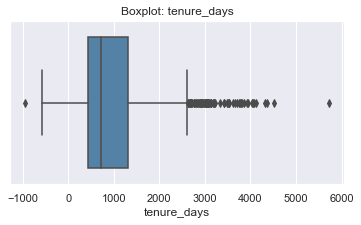

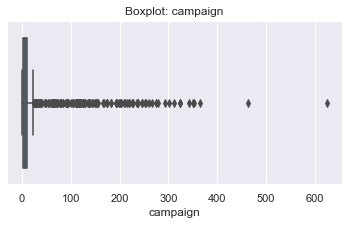

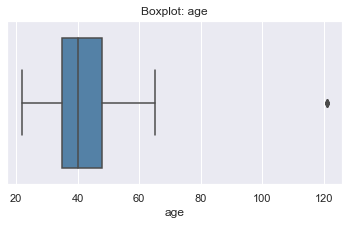

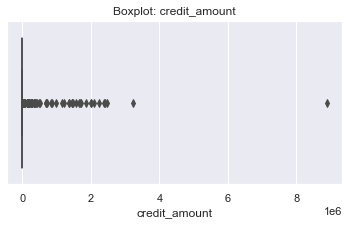

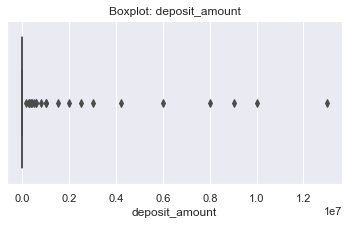

In [57]:
num = ['tenure_days', 'campaign','age', 'credit_amount','deposit_amount']
for col in num:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col], color='steelblue')
    plt.title(f'Boxplot: {col}')
    plt.show()

In [58]:
for col in num:
    p99 = df[col].quantile(0.99)
    outliers_count = (df[col] > p99).sum()
    outliers_pct = outliers_count / len(df) * 100
    
    print(f"{col}: 99-й перцентиль = {p99:.2f}, выбросов = {outliers_count} ({outliers_pct:.2f}%)")

tenure_days: 99-й перцентиль = 3692.84, выбросов = 16 (1.02%)
campaign: 99-й перцентиль = 252.72, выбросов = 16 (1.02%)
age: 99-й перцентиль = 64.00, выбросов = 12 (0.77%)
credit_amount: 99-й перцентиль = 1451424.21, выбросов = 16 (1.02%)
deposit_amount: 99-й перцентиль = 436000.00, выбросов = 16 (1.02%)


Экстремальные значения присутствуют, но их доля около 1%, что не должно значительно искажать модель. Тем не менее, при использовании логистической регрессии такие значения будут смещать среднее, поэтому используем логарифмирование сумм credit_amount/deposit_amount. 

Медиана не чувствительна к выбросам, поэтому пропуски tenure_days заполним медианой. Значения-выбросы в age так же заполним медианой. 

## 3. Валидация и Sklearn Pipeline

In [59]:
train_df = df[df['month'] <= 10]

val_df = df[df['month'] > 10]

Случайное разбиение (train_test_split) приведет к переобучению. Так как в данных имеется историчность. Поэтому обучение происходит на месяцах 1-10, а валидация на 11-12.

In [60]:
cols_to_drop = [

    'campaign','type'
    

]

cols_to_drop = [col for col in cols_to_drop if col in df.columns]

df = df.drop(columns=cols_to_drop)

In [61]:
X_train = train_df.drop(columns=['y'])

y_train = train_df['y']

X_val = val_df.drop(columns=['y'])

y_val = val_df['y']


class ReplaceAnomaly(BaseEstimator, TransformerMixin):

    def __init__(self, anomaly_value=121):

        self.anomaly_value = anomaly_value

 

    def fit(self, X, y=None):

        return self

 

    def transform(self, X):

        X = X.copy()

        X[X == self.anomaly_value] = np.nan

        return X


class NegativeToNan(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):

        return self


    def transform(self, X):

        X = X.copy()

        X[X < 0] = np.nan

        return X


class BinaryMapper(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):

        return self

 

    def transform(self, X):

        X = X.copy()

        return X.replace({'Y': 1, 'N': 0})
    

    

class FreqEncoder(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):

        self.freq_maps_ = {}

        for col in X.columns:

            self.freq_maps_[col] = X[col].value_counts(normalize=True).to_dict()

        return self


    def transform(self, X):

        X_transformed = X.copy()

        for col in X.columns:

            X_transformed[col] = X[col].map(self.freq_maps_[col]).fillna(0)

        return X_transformed


def log_transform(X):

    return np.log1p(X)


numeric_features = ['age', 'tenure_days', 'credit_amount', 'deposit_amount']

numeric_flags = ['is_client_new', 'is_clientfinalta_active', 'was_closed_at_contact']

binary_flags = ['credite_active', 'deposit_active']

categorical_features = ['region', 'source', 'month', 'day']


age_pipe = Pipeline([

    ('fix_121', ReplaceAnomaly(121)),

    ('imputer', SimpleImputer(strategy='median'))

])

 
tenure_pipe = Pipeline([

    ('fix_neg', NegativeToNan()),

    ('imputer', SimpleImputer(strategy='median'))

])


amount_pipe = Pipeline([

    ('log', FunctionTransformer(log_transform, validate=False))

])


flags_pipe = Pipeline([

    ('imputer', SimpleImputer(strategy='most_frequent'))

])

## 4. Обучение и сравнение моделей

In [62]:
class CatBoostPreprocessor(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):

        self.age_median_ = X.loc[X['age'] != 121, 'age'].median()

        self.tenure_median_ = X.loc[X['tenure_days'] >= 0, 'tenure_days'].median()

        return self
    

    def transform(self, X):

        X = X.copy()

        cols_to_drop = ['campaign', 'type']

        for col in cols_to_drop:

            if col in X.columns:

                X = X.drop(columns=[col])

        X['age'] = X['age'].replace(121, self.age_median_)

        X.loc[X['tenure_days'] < 0, 'tenure_days'] = np.nan

        X['tenure_days'] = X['tenure_days'].fillna(self.tenure_median_)

        X['credit_amount'] = np.log1p(X['credit_amount'])

        X['deposit_amount'] = np.log1p(X['deposit_amount'])

        cat_cols = ['region', 'source', 'credite_active', 'deposit_active', 'month', 'day']

        for col in cat_cols:

            if col in X.columns:

                X[col] = X[col].astype(str)

        return X

 
cb_preprocessor = CatBoostPreprocessor()

X_train_cb = cb_preprocessor.fit_transform(X_train)

X_val_cb = cb_preprocessor.transform(X_val)

cat_cols_cb = ['region', 'source', 'credite_active', 'deposit_active', 'month', 'day']

cat_features_indices = [X_train_cb.columns.get_loc(col) for col in cat_cols_cb if col in X_train_cb.columns]

model_cb = CatBoostClassifier(

    iterations=500 , learning_rate=0.05, depth=5, 

    eval_metric='AUC', random_seed=42, verbose=0

)

model_cb.fit(
    X_train_cb, y_train,
    cat_features=['region', 'source', 'credite_active', 'deposit_active', 'month', 'day'],  # ← по ИМЕНАМ!
    eval_set=(X_val_cb, y_val),
    use_best_model=True
)

preds_cb_proba = model_cb.predict_proba(X_val_cb)[:, 1]

model_cb.save_model('catboost_model.cbm')

joblib.dump(cb_preprocessor, 'cb_preprocessor.pkl')

lr_preprocessor = ColumnTransformer(transformers=[

    ('age', Pipeline([('fix_121', ReplaceAnomaly(121)),

                     ('imputer', SimpleImputer(strategy='median')),

                     ('scaler', StandardScaler())]), ['age']),

    ('tenure', Pipeline([('fix_neg', NegativeToNan()),

                        ('imputer', SimpleImputer(strategy='median')),

                        ('scaler', StandardScaler())]), ['tenure_days']),

    ('amount', Pipeline([('log', FunctionTransformer(log_transform, validate=False)),

                        ('scaler', StandardScaler())]), ['credit_amount', 'deposit_amount']),

    ('flags', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),

                       ('scaler', StandardScaler())]), numeric_flags),

    ('binary', Pipeline([('mapper', BinaryMapper()),

                        ('scaler', StandardScaler())]), binary_flags),

    ('cat', Pipeline([('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),

                     ('scaler', StandardScaler())]), ['region', 'source']),

    ('time', Pipeline([('scaler', StandardScaler())]), ['month', 'day'])

], remainder='drop')

lr_pipeline = Pipeline([

    ('preprocessor', lr_preprocessor),

    ('classifier', LogisticRegression(max_iter=1000, solver='liblinear', class_weight='balanced', random_state=42))

])

lr_pipeline.fit(X_train, y_train)

preds_lr_proba = lr_pipeline.predict_proba(X_val)[:, 1]

joblib.dump(lr_pipeline, 'lr_pipeline.pkl')
 
rf_preprocessor = ColumnTransformer(transformers=[

    ('age', Pipeline([('fix_121', ReplaceAnomaly(121)),

                    ('imputer', SimpleImputer(strategy='median'))]), ['age']),

    ('tenure', Pipeline([('fix_neg', NegativeToNan()),

                        ('imputer', SimpleImputer(strategy='median'))]), ['tenure_days']),

    ('amount', Pipeline([('log', FunctionTransformer(log_transform, validate=False))]),

     ['credit_amount', 'deposit_amount']),

    ('flags', Pipeline([('imputer', SimpleImputer(strategy='most_frequent'))]), numeric_flags),

    ('binary', Pipeline([('mapper', BinaryMapper())]), binary_flags),

    ('cat', FreqEncoder(), ['region', 'source'])

], remainder='drop')

rf_pipeline = Pipeline([

    ('preprocessor', rf_preprocessor),

    ('classifier', RandomForestClassifier(n_estimators=500, max_depth=5, min_samples_leaf=30, random_state=42, n_jobs=-1))

])

rf_pipeline.fit(X_train, y_train)

preds_rf_proba = rf_pipeline.predict_proba(X_val)[:, 1]

joblib.dump(rf_pipeline, 'rf_pipeline.pkl')

def evaluate_model_with_best_threshold(y_true, y_proba, model_name):

    auc = roc_auc_score(y_true, y_proba)

    best_f1, best_thresh = 0, 0.5

    for thresh in np.arange(0.05, 0.95, 0.05):

        y_pred_temp = (y_proba >= thresh).astype(int)

        f1_temp = f1_score(y_true, y_pred_temp, zero_division=0)

        if f1_temp > best_f1:

            best_f1 = f1_temp

            best_thresh = thresh

    y_pred = (y_proba >= best_thresh).astype(int)

    acc = accuracy_score(y_true, y_pred)

    precision = precision_score(y_true, y_pred, zero_division=0)

    recall = recall_score(y_true, y_pred, zero_division=0)

    print(f"--- {model_name} ---")

    print(f"ROC-AUC:       {auc:.4f}")

    print(f"Оптимальный порог: {best_thresh:.2f}")

    print(f"Accuracy:      {acc:.4f}")

    print(f"Precision:     {precision:.4f}")

    print(f"Recall:        {recall:.4f}")

    print(f"F1-score:      {f1_score(y_true, y_pred, zero_division=0):.4f}")

    print("-" * 30)

    return {'ROC-AUC': auc, 'Threshold': best_thresh, 'Accuracy': acc,

            'Precision': precision, 'Recall': recall, 'F1-score': best_f1}

metrics_cb = evaluate_model_with_best_threshold(y_val, preds_cb_proba, "CatBoost")

metrics_lr = evaluate_model_with_best_threshold(y_val, preds_lr_proba, "Logistic Regression")

metrics_rf = evaluate_model_with_best_threshold(y_val, preds_rf_proba, "Random Forest")

results_df = pd.DataFrame([metrics_lr, metrics_rf, metrics_cb],

                          index=['Logistic Regression', 'Random Forest', 'CatBoost'])

print(results_df.round(4).sort_values('ROC-AUC', ascending=False))

 

--- CatBoost ---
ROC-AUC:       0.8192
Оптимальный порог: 0.35
Accuracy:      0.8182
Precision:     0.3125
Recall:        0.5000
F1-score:      0.3846
------------------------------
--- Logistic Regression ---
ROC-AUC:       0.7500
Оптимальный порог: 0.55
Accuracy:      0.5455
Precision:     0.2000
Recall:        1.0000
F1-score:      0.3333
------------------------------
--- Random Forest ---
ROC-AUC:       0.5295
Оптимальный порог: 0.05
Accuracy:      0.1477
Precision:     0.1176
Recall:        1.0000
F1-score:      0.2105
------------------------------
                     ROC-AUC  Threshold  Accuracy  Precision  Recall  F1-score
CatBoost              0.8192       0.35    0.8182     0.3125     0.5    0.3846
Logistic Regression   0.7500       0.55    0.5455     0.2000     1.0    0.3333
Random Forest         0.5295       0.05    0.1477     0.1176     1.0    0.2105


## 5. Анализ ошибок и интерпретация

Ложные срабатывания (FP): 11 чел.
Пропущенные клиенты (FN): 5 чел.
Успешно найденные клиенты (TP): 5 чел.



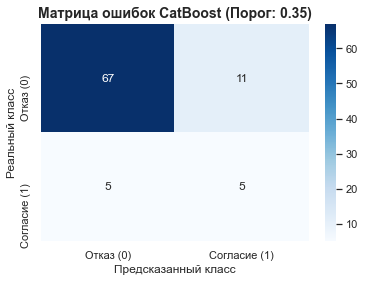

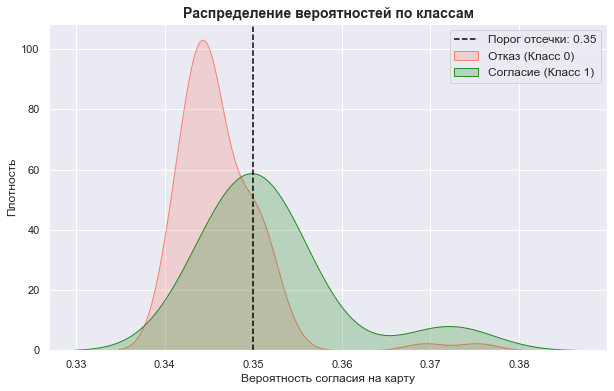

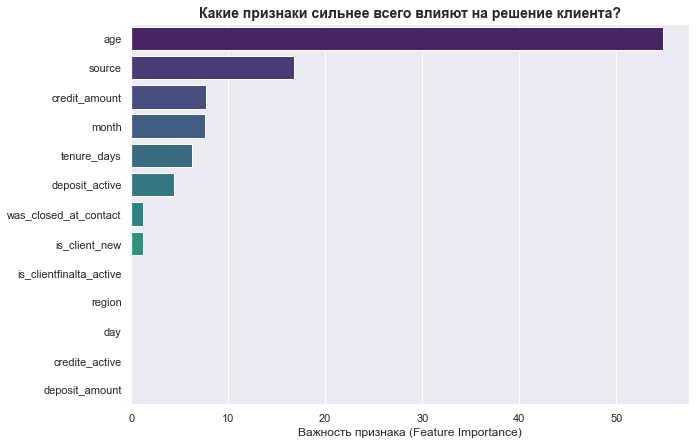

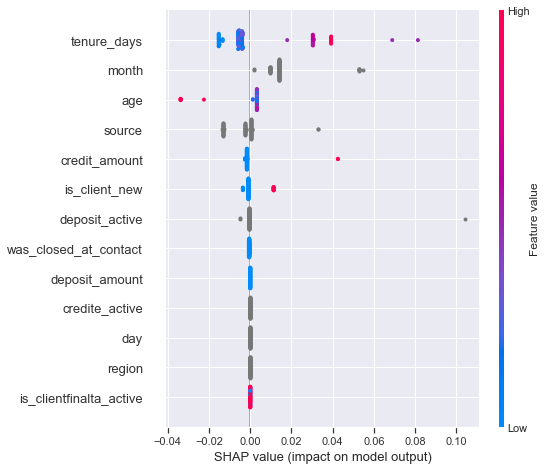

In [63]:
optimal_threshold = 0.35

y_pred_cb = (preds_cb_proba >= optimal_threshold).astype(int)


X_val_analysis = X_val_cb.copy()

X_val_analysis['y_true'] = y_val.values

X_val_analysis['y_pred'] = y_pred_cb


# FP (False Positive): Модель предсказала "Согласится", а клиент отказался

fp_data = X_val_analysis[(X_val_analysis['y_true'] == 0) & (X_val_analysis['y_pred'] == 1)]

# FN (False Negative): Модель сказала "Откажется", а клиент согласился

fn_data = X_val_analysis[(X_val_analysis['y_true'] == 1) & (X_val_analysis['y_pred'] == 0)]

# TP (True Positive): Правильно предсказанные клиенты

tp_data = X_val_analysis[(X_val_analysis['y_true'] == 1) & (X_val_analysis['y_pred'] == 1)]

print(f"Ложные срабатывания (FP): {len(fp_data)} чел.")

print(f"Пропущенные клиенты (FN): {len(fn_data)} чел.")

print(f"Успешно найденные клиенты (TP): {len(tp_data)} чел.\n")


key_features = ['age', 'tenure_days', 'credit_amount', 'deposit_amount']

cm = confusion_matrix(y_val, y_pred_cb)

plt.figure(figsize=(6, 4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',

            xticklabels=['Отказ (0)', 'Согласие (1)'],

            yticklabels=['Отказ (0)', 'Согласие (1)'])

plt.title(f'Матрица ошибок CatBoost (Порог: {optimal_threshold})', fontsize=14, fontweight='bold')

plt.ylabel('Реальный класс', fontsize=12)

plt.xlabel('Предсказанный класс', fontsize=12)

plt.show()

plt.figure(figsize=(10, 6))

sns.kdeplot(preds_cb_proba[y_val == 0], fill=True, color='salmon', label='Отказ (Класс 0)')

sns.kdeplot(preds_cb_proba[y_val == 1], fill=True, color='forestgreen', label='Согласие (Класс 1)')

plt.axvline(x=optimal_threshold, color='black', linestyle='--',

            label=f'Порог отсечки: {optimal_threshold}')

plt.title('Распределение вероятностей по классам', fontsize=14, fontweight='bold')

plt.xlabel('Вероятность согласия на карту', fontsize=12)

plt.ylabel('Плотность', fontsize=12)

plt.legend(fontsize=12)

plt.show()

feature_importance = model_cb.get_feature_importance()

feature_names = X_train_cb.columns

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 7))

sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')

plt.title('Какие признаки сильнее всего влияют на решение клиента?', fontsize=14, fontweight='bold')

plt.xlabel('Важность признака (Feature Importance)', fontsize=12)

plt.ylabel('')

plt.show()

explainer = shap.TreeExplainer(model_cb)

shap_values = explainer.shap_values(X_val_cb)

shap.summary_plot(shap_values, X_val_cb)

Анализ важности признаков показал, что главным признаком является возраст. Это ожидаемо, так как ядро предпринимателей находится в диапазоне 30-50 лет. На втором месте находятся источник лида и сумма кредитов, что подтверждает нацеленность модели на активных бизнес-клиентов с оборотными средствами. Интересно, что модель обнулила важность региона и дня недели, показав, что потребность в бизнес-карте не зависит от географии, а определяется профилем самого клиента.

Бизнес-интерпретация SHAP: 
* Клиенты с действующими кредитами (красная точка справа) с большей вероятностью соглашаются на карту. Им нужны дополнительные средства или рефинансирование. А клиенты без кредитов чаще отказываются.
* График показывает, что давность клиента окрашена в красный цвет справа. Это значит, что клиенты, давно обслуживающиеся в банке, с большей вероятностью примут предложение. 
* Для возраста наблюдается нелинейная зависимость, молодые клиенты более лояльны к кредитам. Клиенты среднего возраста сконцентрированы около нуля, следовательно решение зависит от других факторов. 

**is_clientfinalta_active** Флаг с низкой вариативностью (почти всегда 1). 
Почему не удаляем: Страховка от будущих изменений в данных, если флаг начнёт меняться.

**region** Даёт географический контекст, улучшает интерпретацию source. CatBoost использует комбинации категорий (регион+канал привлечения). Важность комбинации распределяется между признаками неравномерно.

**day** По отдельности не информативен, работает только в паре с month. Вместе с month кодирует сезонность.

**credite_active** Дублирует информацию credit_amount_log. Признак на случай пропусков credit_amount_log в будущих данных. Сумма кредита показывает финансовый размах клиента, поэтому признак оказался важнее просто наличия кредита.

**deposit_amount_log** deposit_active оказался важнее. Клиенту с депозитом легче выдать бизнес-карту, а размер депозита на решение уже не влияет. Может стать важен при масштабировании или в других подвыборках клиентов.


## Калибровка вероятностей

In [64]:
raw_probas_train = model_cb.predict_proba(X_train_cb)[:, 1]
raw_probas_val = model_cb.predict_proba(X_val_cb)[:, 1]

calibrator = IsotonicRegression(out_of_bounds='clip')
calibrator.fit(raw_probas_train, y_train)

probas_cal = calibrator.transform(raw_probas_val)

print(f"Мин: {probas_cal.min():.2%}, Макс: {probas_cal.max():.2%}")
joblib.dump(calibrator,'isotonic_calibrator.pkl')

Мин: 6.87%, Макс: 20.00%


['isotonic_calibrator.pkl']

Обученная модель CatBoost показала ROC-AUC 0.82, что говорит о хорошем качестве ранжирования. Однако анализ предсказаний выявил проблему:
* Исходные вероятности были сгруппированы в узком диапазоне (32-41%). После применения изотонической калибровки диапазон сместился к истинным значениям (6-20%).
Вероятность 20% объективно отражает низкую базовую конверсию в выборке и высокую однородность клиентов (преобладание флага unknown и нулевых сумм). Тем не менее, модель позволяет выделить группу клиентов с вероятностью 20%, которые в 3 раза более склонны к согласию, чем клиенты с вероятностью 6% и таким образом позволяет оптимизировать обзвоны. 

Итоговой моделью выбран CatBoost. При оптимальном пороге 0.35 достигается Recall 50%, то есть находит 5 из 10 потенциальных клиентов. При этом Precision составляет 31%, что означает что каждый 3 звонок оператора по списку модели будет успешным.

## 6. Бизнес влияние и финансовая модель

Базовая конверсия (случайный обзвон): 11.36%
Конверсия при обзвоне топ-30% клиентов по модели: 23.08%
Lift (ускорение): модель работает в 2.03 раз эффективнее случайного обзвона
Прибыль при случайном обзвоне: 46,636,364 руб.
Прибыль при использовании модели: 99,346,154 руб.
Дополнительная прибыль от модели в месяц: 52,709,790 руб.
Дополнительная прибыль за год: 632,517,483 руб.


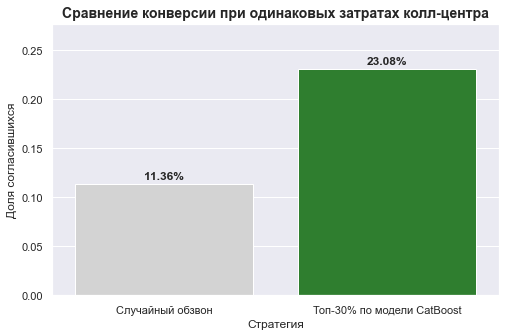

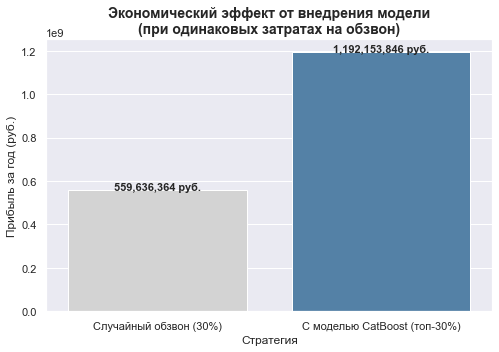

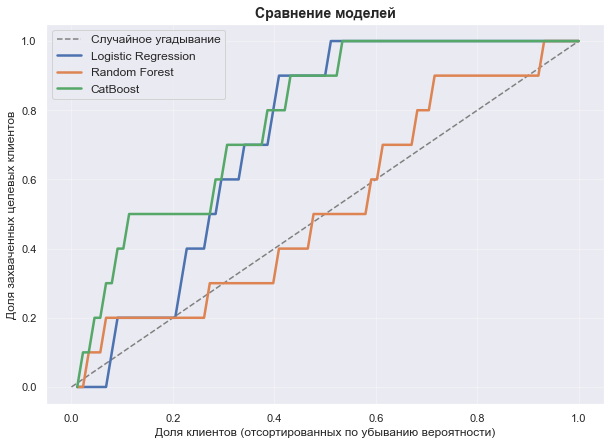

In [65]:
base_conversion = y_val.mean()

val_results = pd.DataFrame({'y_true': y_val.values, 'y_proba': preds_cb_proba})

val_results = val_results.sort_values(by='y_proba', ascending=False)

top_n_percent = 0.30

num_calls_val = int(len(val_results) * top_n_percent)

top_clients = val_results.head(num_calls_val)

model_conversion = top_clients['y_true'].mean()

lift = model_conversion / base_conversion

print(f"Базовая конверсия (случайный обзвон): {base_conversion:.2%}")

print(f"Конверсия при обзвоне топ-{top_n_percent:.0%} клиентов по модели: {model_conversion:.2%}")

print(f"Lift (ускорение): модель работает в {lift:.2f} раз эффективнее случайного обзвона")

cost_per_call = 150

profit_per_success = 15000

bank_monthly_volume = 100000

call_capacity = int(bank_monthly_volume * top_n_percent)

success_without_model = call_capacity * base_conversion

profit_without_model = (success_without_model * profit_per_success) - (call_capacity * cost_per_call)

success_with_model = call_capacity * model_conversion

profit_with_model = (success_with_model * profit_per_success) - (call_capacity * cost_per_call)

extra_profit_monthly = profit_with_model - profit_without_model

print(f"Прибыль при случайном обзвоне: {profit_without_model:,.0f} руб.")

print(f"Прибыль при использовании модели: {profit_with_model:,.0f} руб.")

print(f"Дополнительная прибыль от модели в месяц: {extra_profit_monthly:,.0f} руб.")

print(f"Дополнительная прибыль за год: {extra_profit_monthly * 12:,.0f} руб.")


plt.figure(figsize=(8, 5))

conv_data = pd.DataFrame({

    'Стратегия': ['Случайный обзвон', f'Топ-{top_n_percent:.0%} по модели CatBoost'],

    'Конверсия': [base_conversion, model_conversion]

})

sns.barplot(x='Стратегия', y='Конверсия', data=conv_data, palette=['lightgray', 'forestgreen'])

plt.title('Сравнение конверсии при одинаковых затратах колл-центра', fontsize=14, fontweight='bold')

plt.ylabel('Доля согласившихся', fontsize=12)

plt.ylim(0, model_conversion * 1.2)

for index, row in conv_data.iterrows():

    plt.text(index, row['Конверсия'] + 0.005, f"{row['Конверсия']:.2%}", ha='center', fontsize=12, fontweight='bold')

plt.show()

plt.figure(figsize=(8, 5))

fin_data = pd.DataFrame({

    'Стратегия': ['Случайный обзвон (30%)', f'С моделью CatBoost (топ-{top_n_percent:.0%})'],

    'Годовая прибыль': [profit_without_model * 12, profit_with_model * 12]

})

sns.barplot(x='Стратегия', y='Годовая прибыль', data=fin_data, palette=['lightgray', 'steelblue'])

plt.title('Экономический эффект от внедрения модели\n(при одинаковых затратах на обзвон)', fontsize=14, fontweight='bold')

plt.ylabel('Прибыль за год (руб.)', fontsize=12)

for index, row in fin_data.iterrows():

    plt.text(index, row['Годовая прибыль'] + 500000, f"{row['Годовая прибыль']:,.0f} руб.",

             ha='center', fontsize=11, fontweight='bold')

plt.show()


def plot_cumulative_gain(y_true, y_proba_dict, title):

    plt.figure(figsize=(10, 7))

    plt.plot([0, 1], [0, 1], linestyle='--', label='Случайное угадывание', color='gray')

    for model_name, y_proba in y_proba_dict.items():

        data = pd.DataFrame({'y_true': y_true, 'y_proba': y_proba})

        data = data.sort_values(by='y_proba', ascending=False).reset_index(drop=True)

        data['cumulative_target'] = data['y_true'].cumsum()

        data['cumulative_target_pct'] = data['cumulative_target'] / data['y_true'].sum()

        data['population_pct'] = np.arange(1, len(data) + 1) / len(data)

        plt.plot(data['population_pct'], data['cumulative_target_pct'], label=model_name, linewidth=2.5)

    plt.xlabel('Доля клиентов (отсортированных по убыванию вероятности)', fontsize=12)

    plt.ylabel('Доля захваченных целевых клиентов', fontsize=12)

    plt.title(title, fontsize=14, fontweight='bold')

    plt.legend(fontsize=12)

    plt.grid(True, alpha=0.3)

    plt.show()

proba_dict = {

    'Logistic Regression': preds_lr_proba,

    'Random Forest': preds_rf_proba,

    'CatBoost': preds_cb_proba

}

plot_cumulative_gain(y_val, proba_dict, title='Сравнение моделей')

## 7. Ограничения и дальнейшее развитие

Ограничения:

1. **Высокая однородность клиентского профиля:** большая часть записей в категориальных признаках содержат unknown, а суммы кредитов/депозитов часто равны нулю. Это делает выборку высокооднородной и ограничивает способность модели уверенно разделять классы.
2. **Узкий диапазон вероятностей:** В связи с низкой базовой конверсией (8%), даже лучшие клиенты имеют предсказанную вероятность не больше 20%. Модель не может предсказывать 80%+, так как это не соответствует исторической реальности.
3. **Риск галлюцинации LLM:** Сгенерированные скрипты разговора через GigaChat могут иногда содержать неточности в условиях продукта, что требует контроля со стороны оператора.
    

Дальнейшее развитие:

1. **Обогащение данных:** Добавление поведенческих и исторических признаков (активность в мобильном приложении, частота входов в онлайн-банк, история обращений в поддержку, результаты предыдущих МК, сумма транзакций по картам) для повышения предсказательной силы.
2.**A/B тестирование:** Запуск модели в параллель со случайным обзвоном для замера реального увеличения конверсии (Lift) в реальных условиях.
3. **Контейнеризация и оркестрация:** Упаковка приложения в Docker и деплой в Kubernetes для масштабирования.